# Spatial Gaussian beam-removal map

Grid frequency-mean `|AB_|` onto a 1024×1024 RA/Dec patch spanning **only the
observed pointing bbox**. Amplitudes are **linearly interpolated** from the
real pointings (pixels farther than the typical sample spacing stay NaN), so a
fine lattice does not resolve one circular kernel per pointing at the scan
edge. Then subtract Gaussian leakage from other pixels with a **sum-normalized**
beam so maps stay in the same units as `I`.

Beam width is read from the RA-scan fit JSON (`FWHM_deg` / `sigma_deg`), not hardcoded.

In [1]:
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np

from skymap import Beam, io

beam_fit_path = Path("../outputs/beam_fit_params_ra.json")
datadir = Path("/Users/akshatha.vydula/packages_310/skymap/data_310/TGBT25B_614_01")

start_time = datetime(2026, 1, 16, 18, 9)
end_time = datetime(2026, 1, 16, 18, 52)

beam_file = datadir / "310/beam_obs_2026_01_16.hdf5"

params = Beam.load_beam_fit(beam_fit_path)
print("Fitted FWHM_deg:", params.get("FWHM_deg"))
print("Fitted sigma_deg:", params.get("sigma_deg"))
print("Fitted baseline:", params.get("baseline"))

Fitted FWHM_deg: 0.4979947677159096
Fitted sigma_deg: 0.2114789063252451
Fitted baseline: 34.435483697657


In [2]:
beam_obs = io.read_obs_hdf5(beam_file)
pointing_data = io.get_pointing_data(datadir / "Antenna", start_time, end_time)
beam_obs_pointing = io.match_data_and_pointing(beam_obs, pointing_data)

print("Matched samples:", len(beam_obs_pointing.ra))

Pointing: 33 file(s) (core by filename=33, spill_before=0, spill_after=0) for 2026-01-16 18:09:00 .. 2026-01-16 18:52:00 UTC
  Skipped 1 empty ANTPOSGR table(s): 2026_01_16_17:49:32.fits
  ANTPOSGR rows: 14502 combined -> 14502 with 61056.756250 <= DMJD <= 61056.786111
Matched samples: 14502


In [3]:
result = Beam.map_patch_remove_gaussian_beam(
    beam_obs_pointing,
    params,
    attribute="AB_",
    n_pix=1024,
    reduce="mag_mean",
    niter=1,
)

grid = result["grid"]
attr = result["attribute"]
w = result["weight_sum"][attr]
valid = np.isfinite(result["observed_map"]) & (w > 0)
print("Grid shape:", result["corrected_map"].shape)
print("RA edges:", result["ra_edges"][0], result["ra_edges"][-1])
print("Dec edges:", result["dec_edges"][0], result["dec_edges"][-1])
print("RA pointing min/max:", np.nanmin(beam_obs_pointing.ra), np.nanmax(beam_obs_pointing.ra))
print("Dec pointing min/max:", np.nanmin(beam_obs_pointing.dec), np.nanmax(beam_obs_pointing.dec))
print("max sample distance (deg):", result.get("kernel_sigma_deg"))
print("pixel_size_ra/dec:", result.get("pixel_size_ra_deg"), result.get("pixel_size_dec_deg"))
print("hit pixels:", int(np.count_nonzero(valid)), "/", valid.size)
print("PSF G(0):", result["g00"])
print("Baseline used:", result["baseline"])
print("I min/max:", np.nanmin(result["observed_map"]), np.nanmax(result["observed_map"]))
print("S min/max:", np.nanmin(result["corrected_map"]), np.nanmax(result["corrected_map"]))
print("G⊕S+baseline min/max:", np.nanmin(result["reconvolved_map"]), np.nanmax(result["reconvolved_map"]))
print("I-(G⊕S+baseline) min/max:", np.nanmin(result["residual_map"]), np.nanmax(result["residual_map"]))

Grid shape: (1024, 1024)
RA edges: 255.9395028373422 264.3364103652668
Dec edges: -5.254615808249149 3.271474142035413
RA pointing min/max: 255.9395028373422 264.3364103652668
Dec pointing min/max: -5.254615808249149 3.271474142035413
max sample distance (deg): 0.1122984662167532
pixel_size_ra/dec: 0.008200105007745151 0.008326259717074791
hit pixels: 748588 / 1048576
PSF G(0): 1.0
Baseline used: 34.435483697657
I min/max: 30.81013988336634 164.3551992809118
S min/max: 30.171901973819082 201.84277322380552
G⊕S+baseline min/max: 30.98132085959605 158.95363379812858
I-(G⊕S+baseline) min/max: -14.110753142923429 25.471708399769483


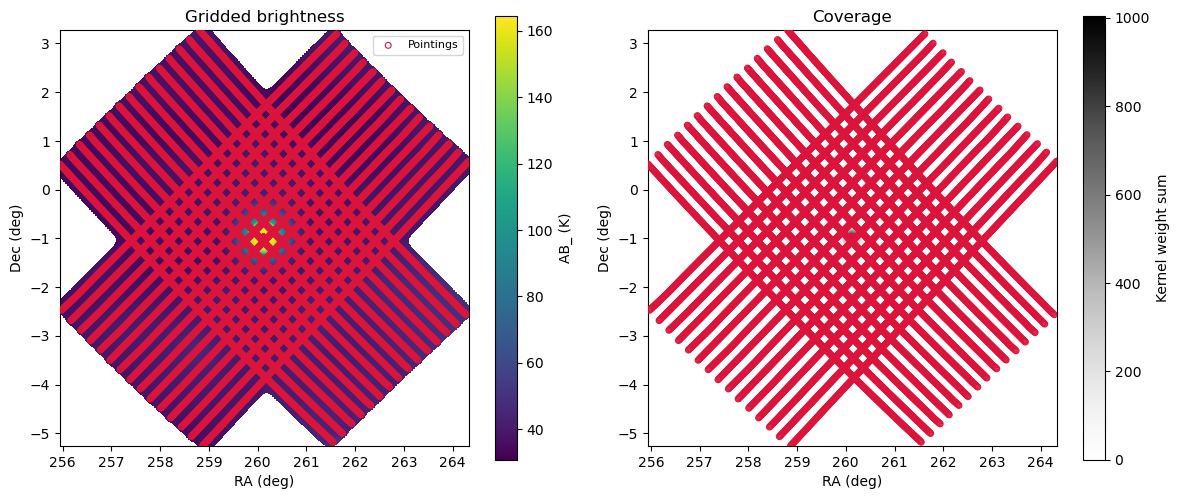

<Figure size 640x480 with 0 Axes>

In [4]:
overlay = (np.asarray(beam_obs_pointing.ra), np.asarray(beam_obs_pointing.dec))
Beam.plot_gridded_map(grid, attr, overlay_pointings=overlay, scale2="linear")
plt.suptitle("Observed |AB_| mean (linear interpolation, observed bbox)")
plt.show()

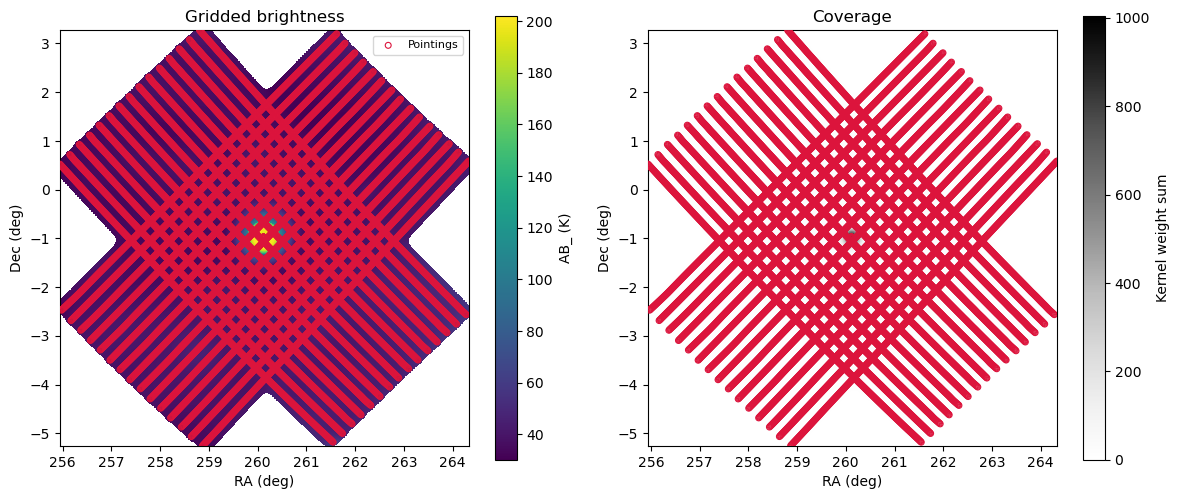

<Figure size 640x480 with 0 Axes>

In [5]:
grid_corr = dict(grid)
grid_corr["maps"] = {attr: result["corrected_map"]}
Beam.plot_gridded_map(grid_corr, attr, overlay_pointings=overlay, scale2="linear")
plt.suptitle("After subtracting Gaussian leakage from other pixels")
plt.show()

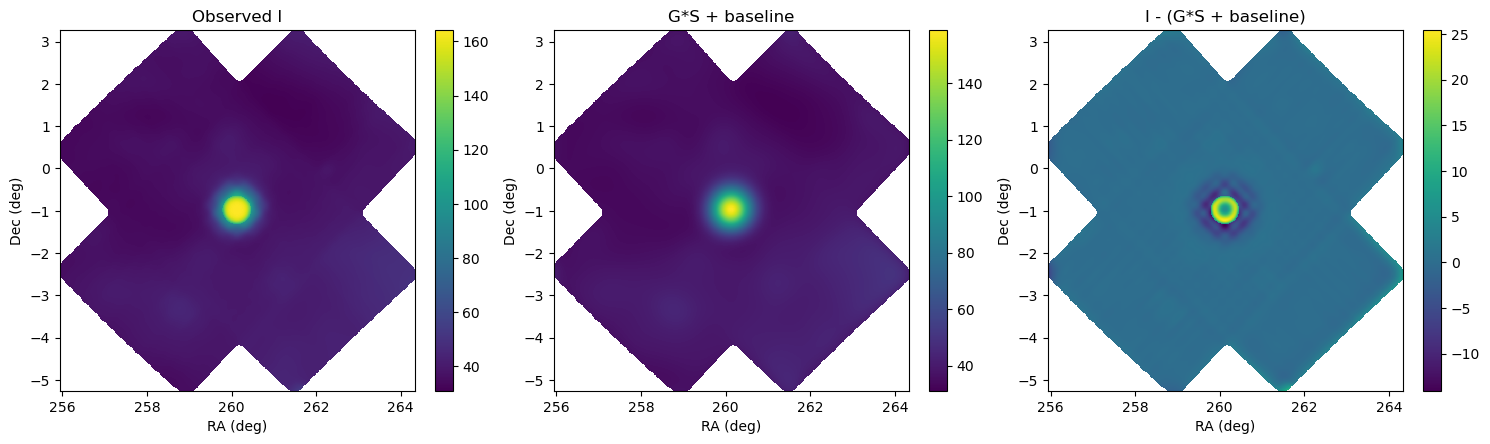

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ra_e = grid["ra_edges"]
dec_e = grid["dec_edges"]
panels = [
    (result["observed_map"], "Observed I"),
    (result["reconvolved_map"], "G*S + baseline"),
    (result["residual_map"], "I - (G*S + baseline)"),
]
for ax, (z, title) in zip(axes, panels):
    pc = ax.pcolormesh(ra_e, dec_e, z, shading="auto")
    ax.set_title(title)
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_aspect("equal")
    fig.colorbar(pc, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Catalog 3C353 RA/Dec: 260.12291666666664 -0.9811111111111112
Map peak RA/Dec: 260.1256564437929 -0.979081443531256 I= 164.3551992809118


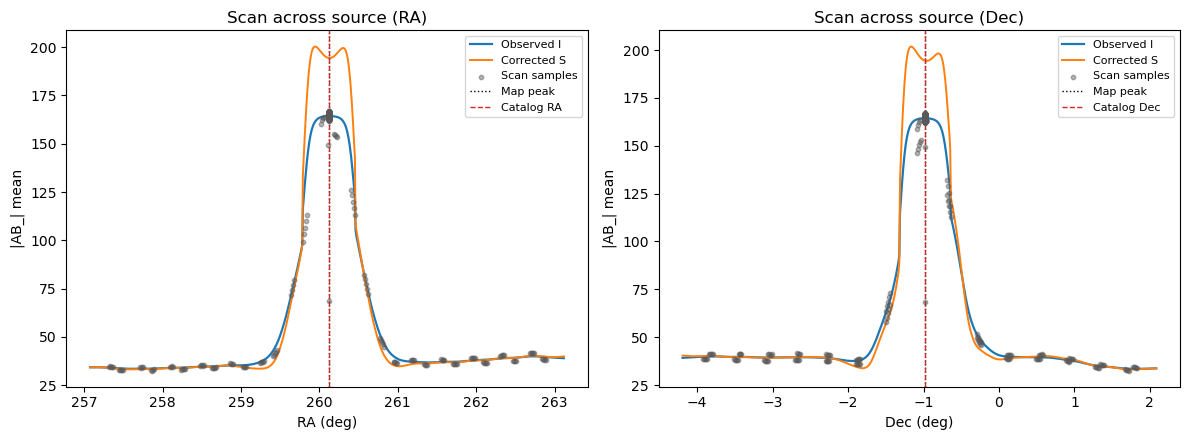

{'source_ra_deg': 260.1256564437929,
 'source_dec_deg': -0.979081443531256,
 'row': 513,
 'col': 510,
 'ra': array([255.94360289, 255.95180299, 255.9600031 , ..., 264.3159101 ,
        264.32411021, 264.33231031], shape=(1024,)),
 'amp_vs_ra': array([nan, nan, nan, ..., nan, nan, nan], shape=(1024,)),
 'dec': array([-5.25045268, -5.24212642, -5.23380016, ...,  3.25065849,
         3.25898475,  3.26731101], shape=(1024,)),
 'amp_vs_dec': array([nan, nan, nan, ..., nan, nan, nan], shape=(1024,)),
 'fig': <Figure size 1200x450 with 2 Axes>,
 'axes': array([<Axes: title={'center': 'Scan across source (RA)'}, xlabel='RA (deg)', ylabel='|AB_| mean'>,
        <Axes: title={'center': 'Scan across source (Dec)'}, xlabel='Dec (deg)', ylabel='|AB_| mean'>],
       dtype=object)}

In [7]:
src_ra, src_dec = Beam.get_source_radec("3C353")
amp = Beam.pol_channel_magnitude_mean(beam_obs_pointing.calibrated_spec_mean, "AB_")
i_pk, j_pk = np.unravel_index(
    int(np.nanargmax(result["observed_map"])), result["observed_map"].shape
)
print("Catalog 3C353 RA/Dec:", src_ra, src_dec)
print(
    "Map peak RA/Dec:",
    result["ra_centers"][j_pk],
    result["dec_centers"][i_pk],
    "I=", result["observed_map"][i_pk, j_pk],
)

# Cuts through the map peak so the profile is the source, not a gap between scans.
Beam.plot_map_source_axis_cuts(
    result["observed_map"],
    result["ra_centers"],
    result["dec_centers"],
    overlay_ra=np.asarray(beam_obs_pointing.ra),
    overlay_dec=np.asarray(beam_obs_pointing.dec),
    overlay_amp=amp,
    extra_maps=[(result["corrected_map"], "Corrected S")],
    mark_ra_deg=src_ra,
    mark_dec_deg=src_dec,
    map_label="Observed I",
    pixel_size_deg=result["pixel_size_deg"],
    ylabel="|AB_| mean",
)

## Observed daisy map (no beam removal)

Reproduce the dirty-sky product: frequency-mean $|AB_*|$ on a lattice with
pixels $\ll$ FWHM, **Gaussian-weighted** onto the grid with a kernel between
the scan-track spacing and the instrument beam (so tracks blend, but 3C353
stays $\sim0.5^\circ$). Low-weight kernel tails are masked. **No** leakage
subtraction. RA increases to the left.

FWHM=0.498 deg, target pixel=0.041 deg, n_pix=205
fill radius (deg): 0.1122984662167532
finite pixels: 30001 / 42025
I min/max: 30.811719658300607 164.33995770072534


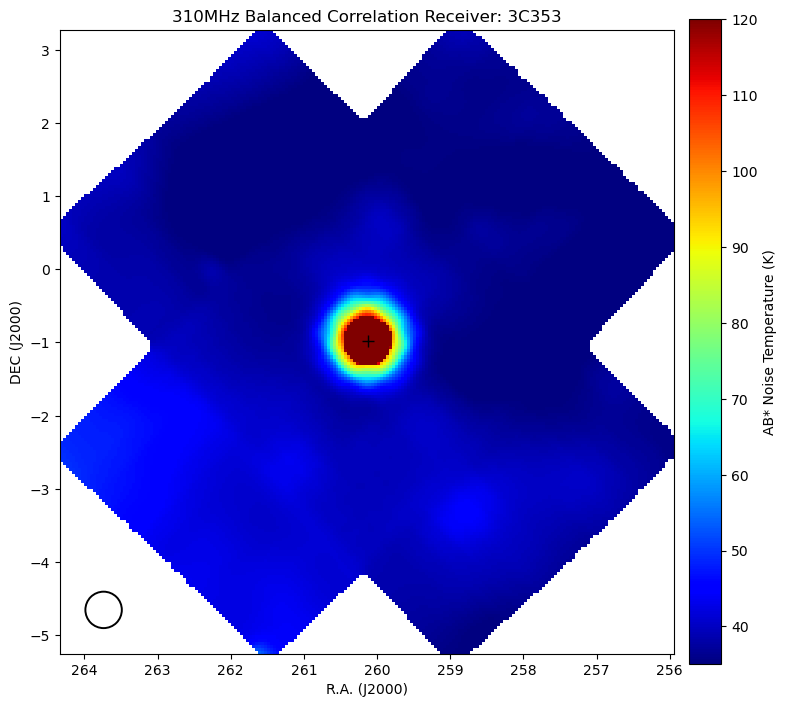

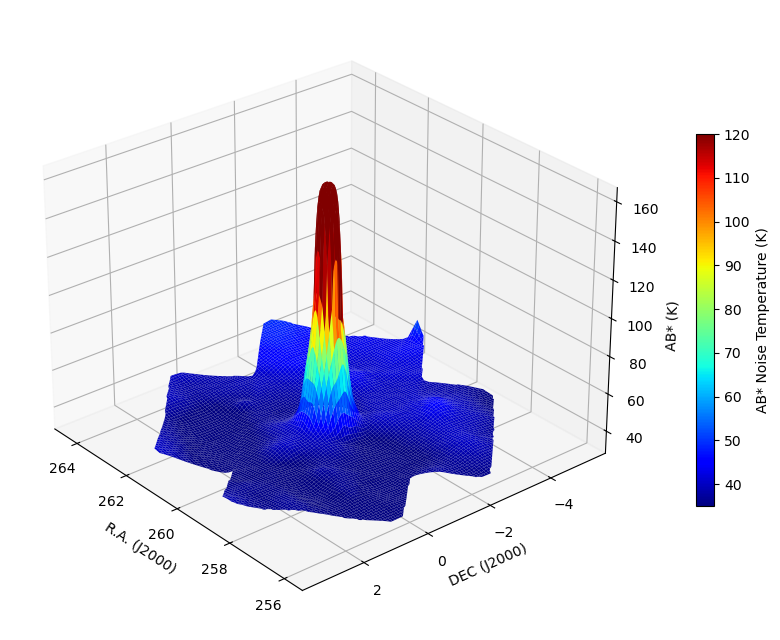

In [20]:
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

src_ra, src_dec = Beam.get_source_radec("3C353")
fwhm = float(params["FWHM_deg"])
sigma = float(params.get("sigma_deg") or fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0))))
pix_target = fwhm / 12.0

ra_u = Beam._unwrap_ra_deg(np.asarray(beam_obs_pointing.ra, dtype=float))
dec_p = np.asarray(beam_obs_pointing.dec, dtype=float)
span = max(
    float(np.nanmax(ra_u) - np.nanmin(ra_u)),
    float(np.nanmax(dec_p) - np.nanmin(dec_p)),
)
n_pix_obs = int(np.clip(np.round(span / pix_target), 128, 512))
print(f"FWHM={fwhm:.3f} deg, target pixel={pix_target:.3f} deg, n_pix={n_pix_obs}")

obs_grid = Beam.grid_patch_fixed_shape(
    beam_obs_pointing,
    params,
    attribute="AB_",
    n_pix=n_pix_obs,
    reduce="mag_mean",
    #kernel_sigma_deg=0.2 * fwhm
)
Z = np.asarray(obs_grid["maps"]["AB_"], dtype=float)
ra_e = np.asarray(obs_grid["ra_edges"], dtype=float)
dec_e = np.asarray(obs_grid["dec_edges"], dtype=float)
ra_c = np.asarray(obs_grid["ra_centers"], dtype=float)
dec_c = np.asarray(obs_grid["dec_centers"], dtype=float)
print("fill radius (deg):", obs_grid["kernel_sigma_deg"])
print("finite pixels:", int(np.count_nonzero(np.isfinite(Z))), "/", Z.size)
print("I min/max:", np.nanmin(Z), np.nanmax(Z))

vmin, vmax = 35.0, 120.0
cmap = plt.cm.jet.copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(8.2, 7.2))
pc = ax.pcolormesh(
    ra_e,
    dec_e,
    np.ma.masked_invalid(Z),
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)
ax.set_aspect("equal")
ax.invert_xaxis()
ax.set_xlabel("R.A. (J2000)")
ax.set_ylabel("DEC (J2000)")
ax.set_title("310MHz Balanced Correlation Receiver: 3C353")
cb = fig.colorbar(pc, ax=ax, pad=0.02)
cb.set_label("AB* Noise Temperature (K)")

# Beam circle (FWHM as diameter), lower-left of the axes after RA inversion.
r_beam = 0.5 * fwhm
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
inset = r_beam + 0.35
circ = Circle(
    (max(x0, x1) - inset, min(y0, y1) + inset),
    r_beam,
    fill=False,
    edgecolor="k",
    lw=1.4,
)
ax.add_patch(circ)
ax.plot(src_ra, src_dec, "k+", ms=8, mew=1.0)
fig.tight_layout()
plt.show()

RA, DEC = np.meshgrid(ra_c, dec_c)
Z3 = np.array(Z, copy=True)
Z3[~np.isfinite(Z3)] = np.nan
fig3 = plt.figure(figsize=(8.5, 6.5))
ax3 = fig3.add_subplot(111, projection="3d")
surf = ax3.plot_surface(
    RA,
    DEC,
    np.ma.masked_invalid(Z3),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    antialiased=True,
    rcount=min(160, Z3.shape[0]),
    ccount=min(160, Z3.shape[1]),
)
ax3.set_xlabel("R.A. (J2000)")
ax3.set_ylabel("DEC (J2000)")
ax3.set_zlabel("AB* (K)")
ax3.view_init(elev=28, azim=140)
fig3.colorbar(surf, ax=ax3, shrink=0.6, pad=0.08, label="AB* Noise Temperature (K)")
plt.tight_layout()
plt.show()

Catalog 3C353 RA/Dec: 260.12291666666664 -0.9811111111111112
Daisy map peak RA/Dec: 260.1379566013045 -0.9915708331068678 I= 164.33995770072534


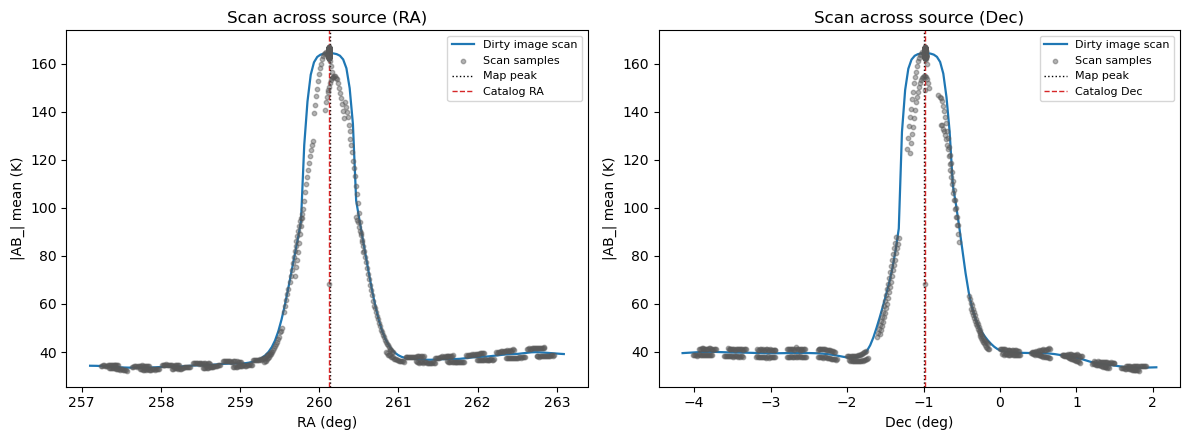

{'source_ra_deg': 260.1379566013045,
 'source_dec_deg': -0.9915708331068678,
 'row': 102,
 'col': 102,
 'ra': array([255.9599831 , 256.00094362, 256.04190415, 256.08286467,
        256.1238252 , 256.16478572, 256.20574625, 256.24670677,
        256.2876673 , 256.32862782, 256.36958834, 256.41054887,
        256.45150939, 256.49246992, 256.53343044, 256.57439097,
        256.61535149, 256.65631202, 256.69727254, 256.73823307,
        256.77919359, 256.82015411, 256.86111464, 256.90207516,
        256.94303569, 256.98399621, 257.02495674, 257.06591726,
        257.10687779, 257.14783831, 257.18879884, 257.22975936,
        257.27071988, 257.31168041, 257.35264093, 257.39360146,
        257.43456198, 257.47552251, 257.51648303, 257.55744356,
        257.59840408, 257.63936461, 257.68032513, 257.72128565,
        257.76224618, 257.8032067 , 257.84416723, 257.88512775,
        257.92608828, 257.9670488 , 258.00800933, 258.04896985,
        258.08993037, 258.1308909 , 258.17185142, 258.21281

In [21]:
amp = Beam.pol_channel_magnitude_mean(beam_obs_pointing.calibrated_spec_mean, "AB_")
i_pk, j_pk = np.unravel_index(int(np.nanargmax(Z)), Z.shape)
print("Catalog 3C353 RA/Dec:", src_ra, src_dec)
print("Daisy map peak RA/Dec:", ra_c[j_pk], dec_c[i_pk], "I=", Z[i_pk, j_pk])

Beam.plot_map_source_axis_cuts(
    Z,
    ra_c,
    dec_c,
    overlay_ra=np.asarray(beam_obs_pointing.ra),
    overlay_dec=np.asarray(beam_obs_pointing.dec),
    overlay_amp=amp,
    mark_ra_deg=src_ra,
    mark_dec_deg=src_dec,
    map_label="Dirty image scan",
    pixel_size_deg=float(obs_grid["pixel_size_deg"]),
    ylabel="|AB_| mean (K)",
)

## Closest match to the provided dirty image

Same `|AB_*|` data and figure style as theirs (jet, 35–110 K, RA to the left,
beam circle, 2D + 3D), with the **track-filling** gridding that worked above:
Gaussian $\sigma$ from the **cross-track** spacing (capped at $0.3\times$FWHM).
A kernel smaller than the daisy-arm spacing leaves gaps and paints one Gaussian
tube per scan — that is what the previous attempt showed.

pixel=0.021 deg, n_pix=411, track spacing=0.112 deg, grid σ=0.075 deg (0.30 × FWHM)
I min/max: 30.723038178461668 164.71056928478743
finite: 117344 / 168921


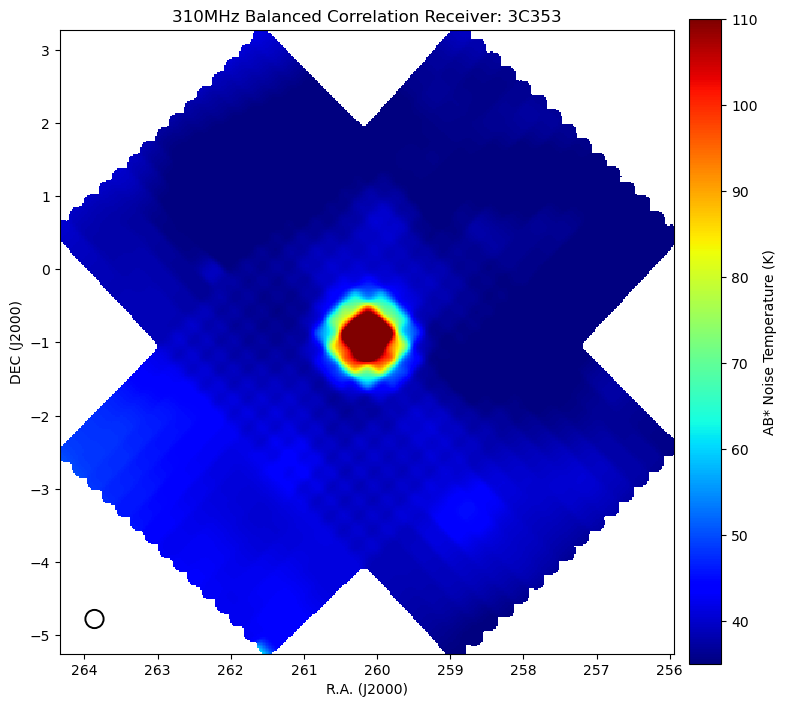

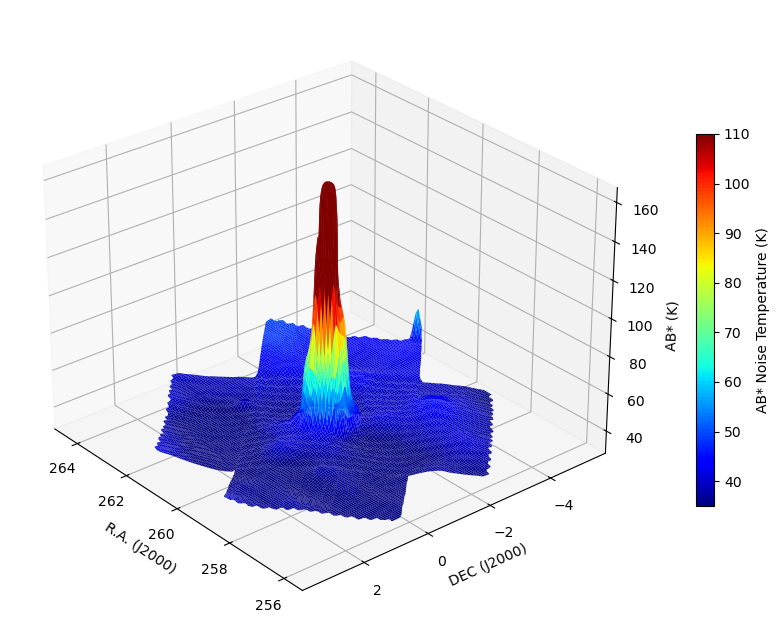

In [10]:
from matplotlib.patches import Circle

src_ra, src_dec = Beam.get_source_radec("3C353")
fwhm = float(params["FWHM_deg"])/2
pix_target = fwhm / 12.0
ra_u = Beam._unwrap_ra_deg(np.asarray(beam_obs_pointing.ra, dtype=float))
dec_p = np.asarray(beam_obs_pointing.dec, dtype=float)
span = max(
    float(np.nanmax(ra_u) - np.nanmin(ra_u)),
    float(np.nanmax(dec_p) - np.nanmin(dec_p)),
)
n_pix_ref = int(np.clip(np.round(span / pix_target), 128, 512))
# Fill between daisy arms: σ from cross-track spacing (same as the map that worked).
# Do not force σ ≪ track spacing — that is what left the striped gaps.
spacing = Beam._characteristic_sample_spacing_deg(ra_u, dec_p)
sigma_ref = max(spacing, 1.5 * pix_target)
sigma_ref = min(sigma_ref, 0.30 * fwhm)
print(
    f"pixel={pix_target:.3f} deg, n_pix={n_pix_ref}, "
    f"track spacing={spacing:.3f} deg, grid σ={sigma_ref:.3f} deg "
    f"({sigma_ref / fwhm:.2f} × FWHM)"
)

ref_grid = Beam.grid_patch_fixed_shape(
    beam_obs_pointing,
    params,
    attribute="AB_",
    n_pix=n_pix_ref,
    reduce="mag_mean",
    kernel_sigma_deg=sigma_ref,
)
Z = np.asarray(ref_grid["maps"]["AB_"], dtype=float)
ra_e = np.asarray(ref_grid["ra_edges"], dtype=float)
dec_e = np.asarray(ref_grid["dec_edges"], dtype=float)
ra_c = np.asarray(ref_grid["ra_centers"], dtype=float)
dec_c = np.asarray(ref_grid["dec_centers"], dtype=float)
print("I min/max:", np.nanmin(Z), np.nanmax(Z))
print("finite:", int(np.count_nonzero(np.isfinite(Z))), "/", Z.size)

vmin, vmax = 35.0, 110.0
cmap = plt.cm.jet.copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(8.2, 7.2))
pc = ax.pcolormesh(
    ra_e,
    dec_e,
    np.ma.masked_invalid(Z),
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)
ax.set_aspect("equal")
ax.invert_xaxis()
ax.set_xlabel("R.A. (J2000)")
ax.set_ylabel("DEC (J2000)")
ax.set_title("310MHz Balanced Correlation Receiver: 3C353")
cb = fig.colorbar(pc, ax=ax, pad=0.02)
cb.set_label("AB* Noise Temperature (K)")
r_beam = 0.5 * fwhm
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
inset = r_beam + 0.35
ax.add_patch(
    Circle(
        (max(x0, x1) - inset, min(y0, y1) + inset),
        r_beam,
        fill=False,
        edgecolor="k",
        lw=1.4,
    )
)
fig.tight_layout()
plt.show()

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

RA, DEC = np.meshgrid(ra_c, dec_c)
Z3 = np.array(Z, copy=True)
fig3 = plt.figure(figsize=(8.5, 6.5))
ax3 = fig3.add_subplot(111, projection="3d")
surf = ax3.plot_surface(
    RA,
    DEC,
    np.ma.masked_invalid(Z3),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    antialiased=True,
    rcount=min(140, Z3.shape[0]),
    ccount=min(140, Z3.shape[1]),
)
ax3.set_xlabel("R.A. (J2000)")
ax3.set_ylabel("DEC (J2000)")
ax3.set_zlabel("AB* (K)")
ax3.view_init(elev=28, azim=140)
fig3.colorbar(surf, ax=ax3, shrink=0.6, pad=0.08, label="AB* Noise Temperature (K)")
plt.tight_layout()
plt.show()

method: bin_linear
fill radius (deg): 0.1122984662167532
I min/max: 30.661681480291577 164.86764434598828


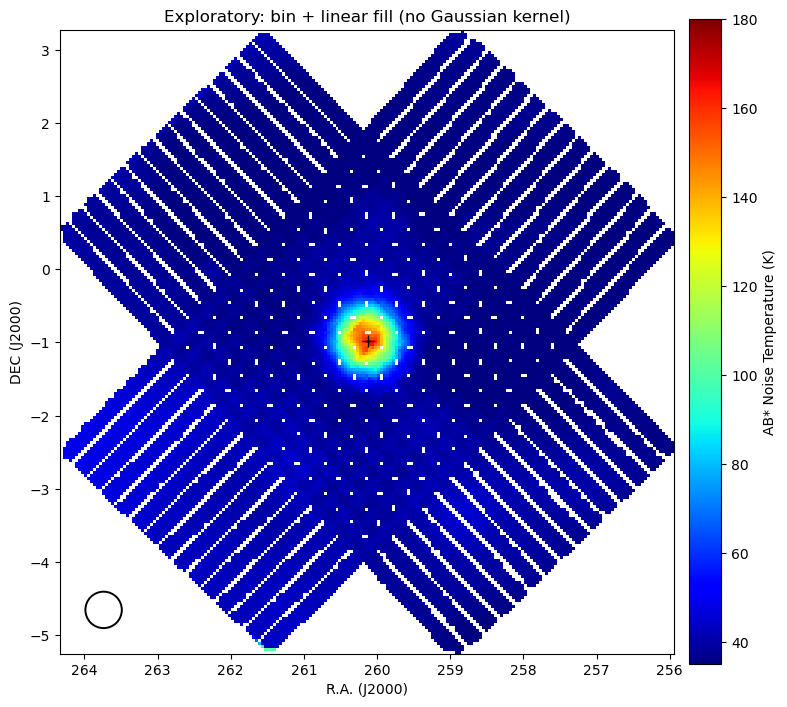

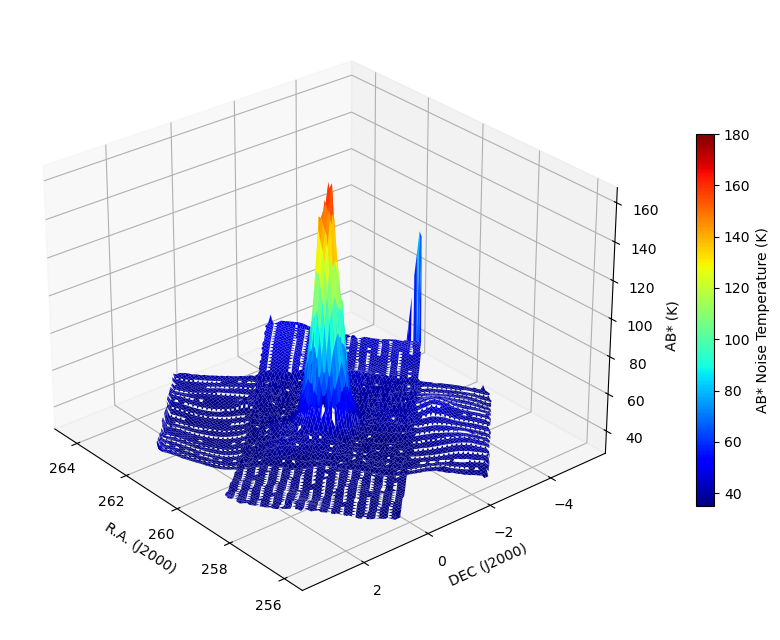

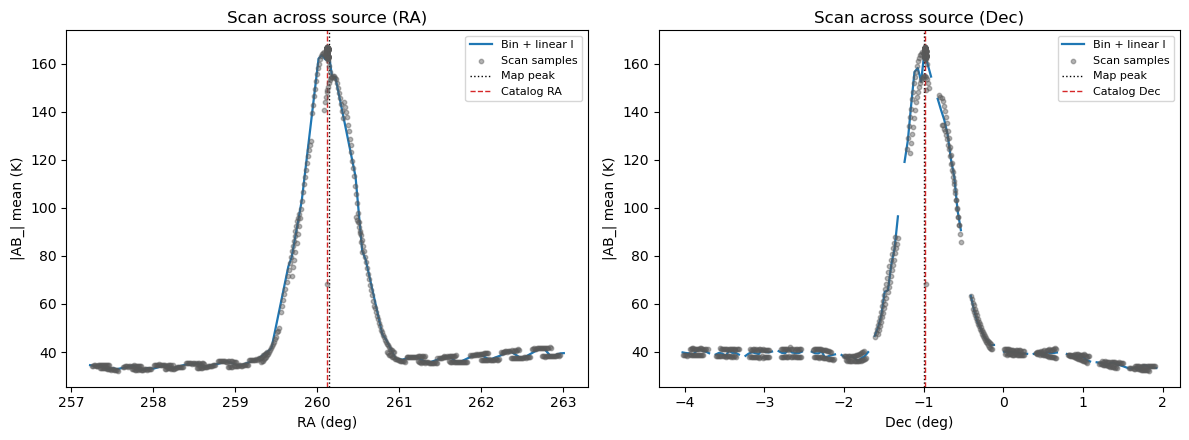

{'source_ra_deg': 260.1379566013045,
 'source_dec_deg': -0.9915708331068678,
 'row': 102,
 'col': 102,
 'ra': array([255.9599831 , 256.00094362, 256.04190415, 256.08286467,
        256.1238252 , 256.16478572, 256.20574625, 256.24670677,
        256.2876673 , 256.32862782, 256.36958834, 256.41054887,
        256.45150939, 256.49246992, 256.53343044, 256.57439097,
        256.61535149, 256.65631202, 256.69727254, 256.73823307,
        256.77919359, 256.82015411, 256.86111464, 256.90207516,
        256.94303569, 256.98399621, 257.02495674, 257.06591726,
        257.10687779, 257.14783831, 257.18879884, 257.22975936,
        257.27071988, 257.31168041, 257.35264093, 257.39360146,
        257.43456198, 257.47552251, 257.51648303, 257.55744356,
        257.59840408, 257.63936461, 257.68032513, 257.72128565,
        257.76224618, 257.8032067 , 257.84416723, 257.88512775,
        257.92608828, 257.9670488 , 258.00800933, 258.04896985,
        258.08993037, 258.1308909 , 258.17185142, 258.21281

In [11]:
# Exploratory: bin samples (peak = in-bin mean), then linearly fill track gaps.
# No Gaussian gridding kernel. Does not change the Observed daisy map cell.
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

src_ra, src_dec = Beam.get_source_radec("3C353")
fwhm = float(params["FWHM_deg"])
pix_target = fwhm / 12.0
ra_u = Beam._unwrap_ra_deg(np.asarray(beam_obs_pointing.ra, dtype=float))
dec_p = np.asarray(beam_obs_pointing.dec, dtype=float)
span = max(
    float(np.nanmax(ra_u) - np.nanmin(ra_u)),
    float(np.nanmax(dec_p) - np.nanmin(dec_p)),
)
n_pix_exp = int(np.clip(np.round(span / pix_target), 128, 512))

exp_grid = Beam.grid_patch_fixed_shape(
    beam_obs_pointing,
    params,
    attribute="AB_",
    n_pix=n_pix_exp,
    reduce="mag_mean",
    method="bin_linear",
)
Z_exp = np.asarray(exp_grid["maps"]["AB_"], dtype=float)
ra_e = np.asarray(exp_grid["ra_edges"], dtype=float)
dec_e = np.asarray(exp_grid["dec_edges"], dtype=float)
ra_c_exp = np.asarray(exp_grid["ra_centers"], dtype=float)
dec_c_exp = np.asarray(exp_grid["dec_centers"], dtype=float)
print("method:", exp_grid.get("method"))
print("fill radius (deg):", exp_grid["kernel_sigma_deg"])
print("I min/max:", np.nanmin(Z_exp), np.nanmax(Z_exp))

vmin, vmax = 35.0, 180.0
cmap = plt.cm.jet.copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(8.2, 7.2))
pc = ax.pcolormesh(
    ra_e,
    dec_e,
    np.ma.masked_invalid(Z_exp),
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)
ax.set_aspect("equal")
ax.invert_xaxis()
ax.set_xlabel("R.A. (J2000)")
ax.set_ylabel("DEC (J2000)")
ax.set_title("Exploratory: bin + linear fill (no Gaussian kernel)")
cb = fig.colorbar(pc, ax=ax, pad=0.02)
cb.set_label("AB* Noise Temperature (K)")
r_beam = 0.5 * fwhm
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
inset = r_beam + 0.35
ax.add_patch(
    Circle(
        (max(x0, x1) - inset, min(y0, y1) + inset),
        r_beam,
        fill=False,
        edgecolor="k",
        lw=1.4,
    )
)
ax.plot(src_ra, src_dec, "k+", ms=8, mew=1.0)
fig.tight_layout()
plt.show()

RA, DEC = np.meshgrid(ra_c_exp, dec_c_exp)
fig3 = plt.figure(figsize=(8.5, 6.5))
ax3 = fig3.add_subplot(111, projection="3d")
surf = ax3.plot_surface(
    RA,
    DEC,
    np.ma.masked_invalid(Z_exp),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
    linewidth=0,
    antialiased=True,
    rcount=min(160, Z_exp.shape[0]),
    ccount=min(160, Z_exp.shape[1]),
)
ax3.set_xlabel("R.A. (J2000)")
ax3.set_ylabel("DEC (J2000)")
ax3.set_zlabel("AB* (K)")
ax3.view_init(elev=28, azim=140)
fig3.colorbar(surf, ax=ax3, shrink=0.6, pad=0.08, label="AB* Noise Temperature (K)")
plt.tight_layout()
plt.show()

amp = Beam.pol_channel_magnitude_mean(beam_obs_pointing.calibrated_spec_mean, "AB_")
Beam.plot_map_source_axis_cuts(
    Z_exp,
    ra_c_exp,
    dec_c_exp,
    overlay_ra=np.asarray(beam_obs_pointing.ra),
    overlay_dec=np.asarray(beam_obs_pointing.dec),
    overlay_amp=amp,
    mark_ra_deg=src_ra,
    mark_dec_deg=src_dec,
    map_label="Bin + linear I",
    pixel_size_deg=float(exp_grid["pixel_size_deg"]),
    ylabel="|AB_| mean (K)",
)